
#### Assignment 3 - RNN
**Mahshid Bargahi**

In this notebook, we investigate the performance of different recurrent neural network architectures on a text classification task using the **BBC News Dataset**. The objective is to compare traditional and gated recurrent models and analyze how key sequence-modeling hyperparameters influence performance.

## Import Libraries

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set(color_codes=True)

## Loading the dataset

In [42]:
data = pd.read_csv(r"D:\sharif\ADS\assignments\assignment3\RNN\bbc-text.csv")
data.head()

,category,text
0,tech,tv future in the hands of viewers with home th...
1,business,worldcom boss left books alone former worldc...
2,sport,tigers wary of farrell gamble leicester say ...
3,sport,yeading face newcastle in fa cup premiership s...
4,entertainment,ocean s twelve raids box office ocean s twelve...


## Getting some insight frome data

In [43]:
data.shape

(2225, 2)

In [44]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2225 entries, 0 to 2224
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   category  2225 non-null   object
 1   text      2225 non-null   object
dtypes: object(2)
memory usage: 34.9+ KB


In [45]:
data.isnull().sum()

category    0
text        0
dtype: int64

Ok, There is'nt missing value.

Let's see distribution of categories.

In [46]:
labels = data["category"].unique()

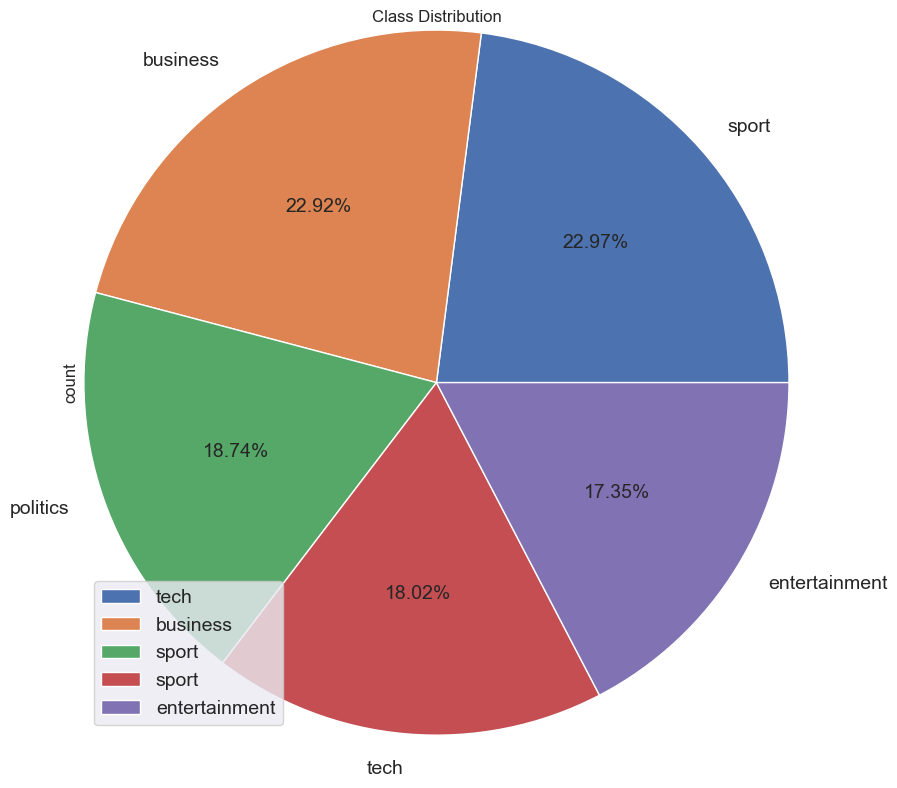

In [47]:
categories_count = data["category"].value_counts()

categories_count.plot(kind = 'pie', figsize=(12,8), autopct='%1.2f%%', radius=1.25, labels=categories_count.index, fontsize=14)
plt.title("Class Distribution")
plt.legend(data['category'],loc='lower left',fontsize=14)
plt.tight_layout()
plt.show()

The dataset looks balanced, prety good.

Now let's check the number of words per article.

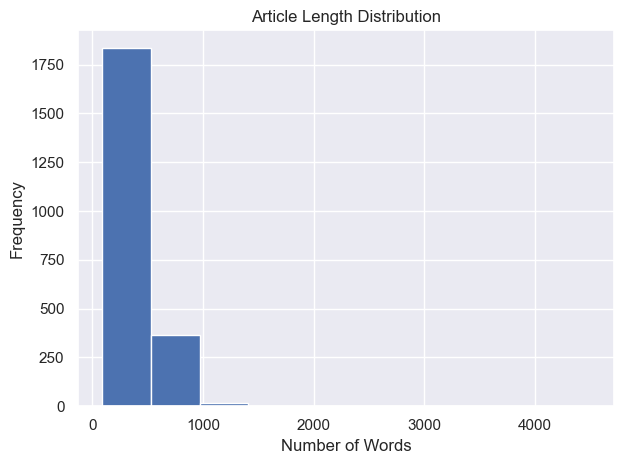

In [48]:
data["word_count"] = data["text"].apply( lambda x: len(str(x).split()))

plt.hist(data["word_count"], bins=10)
plt.title("Article Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

As we see, most of articles have between 100 to 500 words. Also there are some text with too long length.

## Preprocessing the Texts

In [49]:
# convert all words to lower case
data["text"] = data["text"].str.lower()

In [50]:
import re

url_pattern = r'http\S+|www\.\S+'

samples_with_url = data[data['text'].str.contains(url_pattern, regex=True, na=False)]
print(samples_with_url.shape)

(3, 3)


There are some samples with URLs like http,.. . Let's remove them.

In [51]:
def remove_urls(text):
    return re.sub(url_pattern, '', str(text))

data["text"] = data["text"].apply(remove_urls)

In [52]:
# remove punctuation in texts
def remove_punctuation(text):
    return re.sub(r'[^\w\s]', '', text)

data["text"] = data["text"].apply(remove_punctuation)

In [53]:
# remove extra spaces in texts
def clean_spaces(text):
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'\d+', '', text).strip()
    return text

data["text"] = data["text"].apply(clean_spaces)

## Encoding the categories

In [54]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

data['label'] = encoder.fit_transform(data['category'])

In [55]:
data['label'].head()

0    4
1    0
2    3
3    3
4    1
Name: label, dtype: int64

In [56]:
NUM_CLASSES = len(encoder.classes_)
print(NUM_CLASSES)

5


## Train/Test Split

In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data['text'], data['label'],
    test_size=0.2,
    random_state=42,
    stratify=data["label"])  # preserves class proportions

### Tokenization 

Neural networks cannot process raw text directly. Therefore, the textual articles must be converted into numerical representations.

- We use Keras Tokenizer to create a vocabulary from the training data.

Our vocabulary maybe like this:

| Word | Index |
|--------|--------|
| `<OOV>` | 1 |
| the | 2 |
| cat | 3 |
| sat | 4 |
| dog | 5 |
| ran | 6 |

In [58]:
from tensorflow.keras.preprocessing.text import Tokenizer

# only the 10,000 most frequent words are kept in the vocabulary
MAX_WORDS = 10000

# if model sees the word that were never seen during training the word is mapped to a special token(<OOV>)
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

In [59]:
# each article is transformed into a sequence of integers
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

Let's check sequence lengths and vocabulary size.

In [60]:
print(len(tokenizer.word_index))

27594


In [61]:
lengths = [len(seq) for seq in X_train_seq]
pd.Series(lengths).describe()

count    1780.000000
mean      383.703371
std       250.101393
min        89.000000
25%       244.000000
50%       331.000000
75%       466.250000
max      4449.000000
dtype: float64

Squenses have average length 384 but there are some outliers with length=4450. So we use padding to make all sequences the same length.

In [62]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_LEN = 200

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding='post', # it keeps the beginning of the article and appends zeros at the end
    truncating='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

In [63]:
print(X_train_pad.shape)
print(X_test_pad.shape)
pd.DataFrame(X_train_pad).head()

(1780, 200)
(445, 200)


,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
0,443,659,9,1,3151,2,678,4,905,7517,...,0,0,0,0,0,0,0,0,0,0
1,1665,23,1789,1666,292,2,238,708,4,1337,...,2,1665,8,292,19,29,5512,26,91,108
2,2961,287,8417,2171,2,857,2171,20,1602,34,...,92,1965,576,8420,1094,1848,1,246,2,92
3,1,63,383,3051,1,5,1,63,418,656,...,8,92,327,2,1413,2648,588,99,8421,58
4,252,1,387,217,1353,372,252,20,2378,1353,...,46,45,143,31,1,3,17,3539,139,139


# Modeling with Keras

We use keras to build our models.

First we define some functions to evalute and plot models outputs.

In [64]:
def plot_learning_curves(model_name, history):

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Accuracy
    axes[0].plot(history.history['accuracy'], label='Train Accuracy')
    axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axes[0].set_title('Training and Validation Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()

    # Loss
    axes[1].plot(history.history['loss'], label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Validation Loss')
    axes[1].set_title('Training and Validation Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()

    fig.suptitle(f"{model_name} Learning curves")
    plt.tight_layout()
    plt.show()

In [65]:
from sklearn.metrics import ConfusionMatrixDisplay

def plot_confusion(y_true, y_pred, model_name):
    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        display_labels=labels,
        cmap="Blues"
    )

    plt.title(f"{model_name} Confusion Matrix")
    plt.show()    

In [66]:
from sklearn.metrics import f1_score

def model_evalute(model, name, results):
    test_loss, test_acc = model.evaluate(
    X_test_pad,
    y_test,
    verbose=0
    )

    y_pred_probs = model.predict(X_test_pad)
    y_pred = np.argmax(y_pred_probs, axis=1)

    f1 = f1_score(y_test, y_pred, average='weighted') # since classes are fairly balanced

    results[name] = {
        "Test Accuracy":test_acc,
        "Test Loss":test_loss,
        "F1 Score": f1
    }
    return results

## Vanilla RNN 

We buils simple RNN (or Vanilla RNN) using :

- **Embedding layer :** It converts each token index into a dense vector representation. The model learns a continuous 64-dimensional representation for each word during training.
- **input_dim=MAX_WORDS :** The vocabulary is limited to the 10,000 most frequent words in the training corpus.
- **output_dim=64 :** Each word is represented by a 64-dimensional embedding vector.
- **input_length=MAX_LEN :** Defines the maximum sequence length after padding.
- **mask_zero=True :** Padding tokens (value 0) are ignored by subsequent recurrent layers, preventing the model from learning from artificial padding.


- The final Dense layer maps the learned sequence representation to the target classes :
- **NUM_CLASSES** corresponds to the number of news categories in the dataset.
- The **softmax** activation converts the outputs into a probability distribution over all classes.

In [67]:
import tensorflow as tf 
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dense,SimpleRNN, Embedding

rnn_model = Sequential()

rnn_model.add(Embedding(input_dim=MAX_WORDS, output_dim=64, input_length=MAX_LEN, mask_zero=True))

# a rnn layer with hidden size of 64 units
rnn_model.add(SimpleRNN(64))

rnn_model.add(Dense(NUM_CLASSES, activation='softmax'))

rnn_model.build(input_shape=(None, MAX_LEN))
rnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,581 (2.47 MB)

 Trainable params: 648,581 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

Our problem is multiclass classification ,So we use 'sparse_categorical_crossentropy' as loss function.

In [68]:
from tensorflow.keras.optimizers import Adam 

rnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    metrics=['accuracy']
)

We define an early stopping to to prevent overfitting and reduce unnecessary training.

In [71]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True  #the weights corresponding to the best validation performance were restored
)

In [72]:
history_rnn = rnn_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    callbacks=[early_stopping]
)

Epoch 1/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 149ms/step - accuracy: 0.9312 - loss: 0.7664 - val_accuracy: 0.3989 - val_loss: 1.3798
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 136ms/step - accuracy: 0.9670 - loss: 0.6551 - val_accuracy: 0.4298 - val_loss: 1.3633
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 154ms/step - accuracy: 0.9817 - loss: 0.5565 - val_accuracy: 0.4354 - val_loss: 1.3428
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 138ms/step - accuracy: 0.9888 - loss: 0.4720 - val_accuracy: 0.4522 - val_loss: 1.3296
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 112ms/step - accuracy: 0.9958 - loss: 0.3928 - val_accuracy: 0.4607 - val_loss: 1.3309
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 122ms/step - accuracy: 0.9972 - loss: 0.3333 - val_accuracy: 0.4579 - val_loss: 1.3454
Epoch 7/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 184ms/step - accuracy: 0.9986 - loss: 0.2861 - val_accuracy: 0.4494 - val_loss: 1.3898


Let's check learning curve.

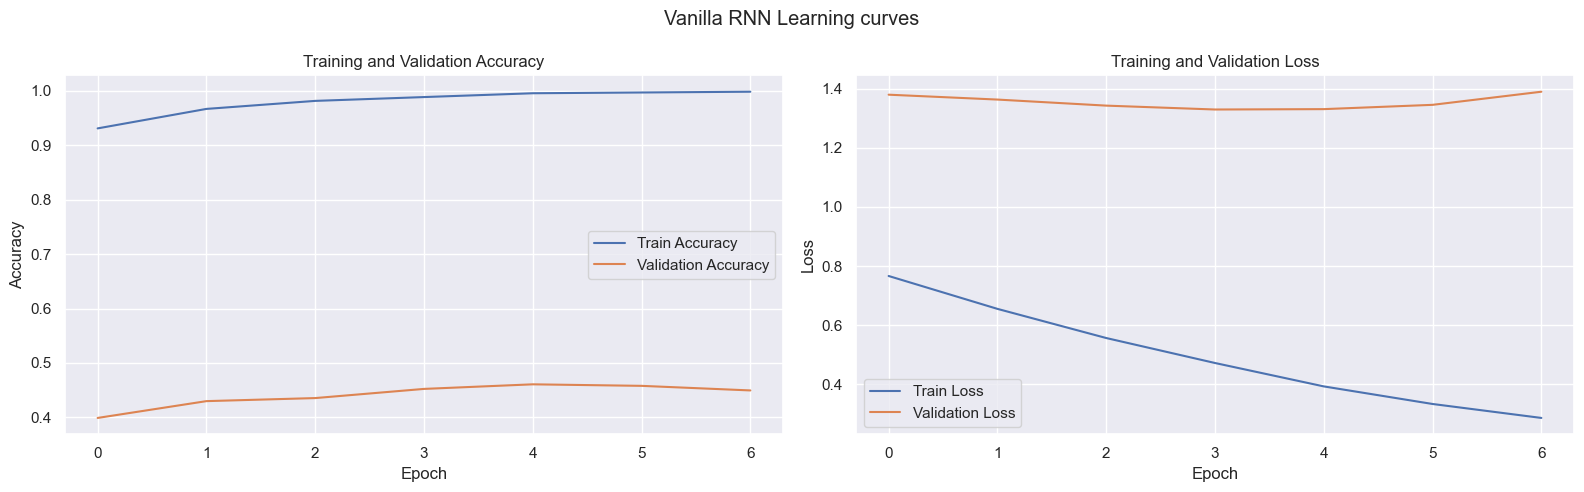

In [73]:
plot_learning_curves("Vanilla RNN", history_rnn)

In [74]:
results = {}
results = model_evalute(rnn_model, "Vanilla RNN", results)
pd.DataFrame(results).T

14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step


,Test Accuracy,Test Loss,F1 Score
Vanilla RNN,0.469663,1.268375,0.46591


The Vanilla RNN achieved a test accuracy of 47.0% and a weighted F1-score of 46.6%. Training and validation curves indicate overfitting, as training accuracy continued to improve while validation accuracy declined after approximately 5 epochs.

## LSTM

LSTMs introduce memory cells and gating mechanisms that allow important information to be preserved across longer sequences.

- Like Vanilla RNN , we use an embedding layer to converts each word index into a dense vector representation.
- We set a LSTM layer with hidden size 64 units like Vanilla RNN.
- And the same output layer.

In [75]:
from tensorflow.keras.layers import LSTM

lstm_model = Sequential()

lstm_model.add(Embedding(input_dim=MAX_WORDS, output_dim=64, input_length=MAX_LEN, mask_zero=True))

# a lstm layer with hidden size of 64 units
lstm_model.add(LSTM(64))

lstm_model.add(Dense(NUM_CLASSES, activation='softmax'))


lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lstm_model.build(input_shape=(None, MAX_LEN))
lstm_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673,349 (2.57 MB)

 Trainable params: 673,349 (2.57 MB)

 Non-trainable params: 0 (0.00 B)

In [76]:
history_lstm = lstm_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    callbacks=[early_stopping]
)

Epoch 1/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 17s 273ms/step - accuracy: 0.2226 - loss: 1.6082 - val_accuracy: 0.2303 - val_loss: 1.6088
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 236ms/step - accuracy: 0.2662 - loss: 1.6043 - val_accuracy: 0.2247 - val_loss: 1.6076
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 23s 292ms/step - accuracy: 0.3069 - loss: 1.5994 - val_accuracy: 0.2500 - val_loss: 1.6057


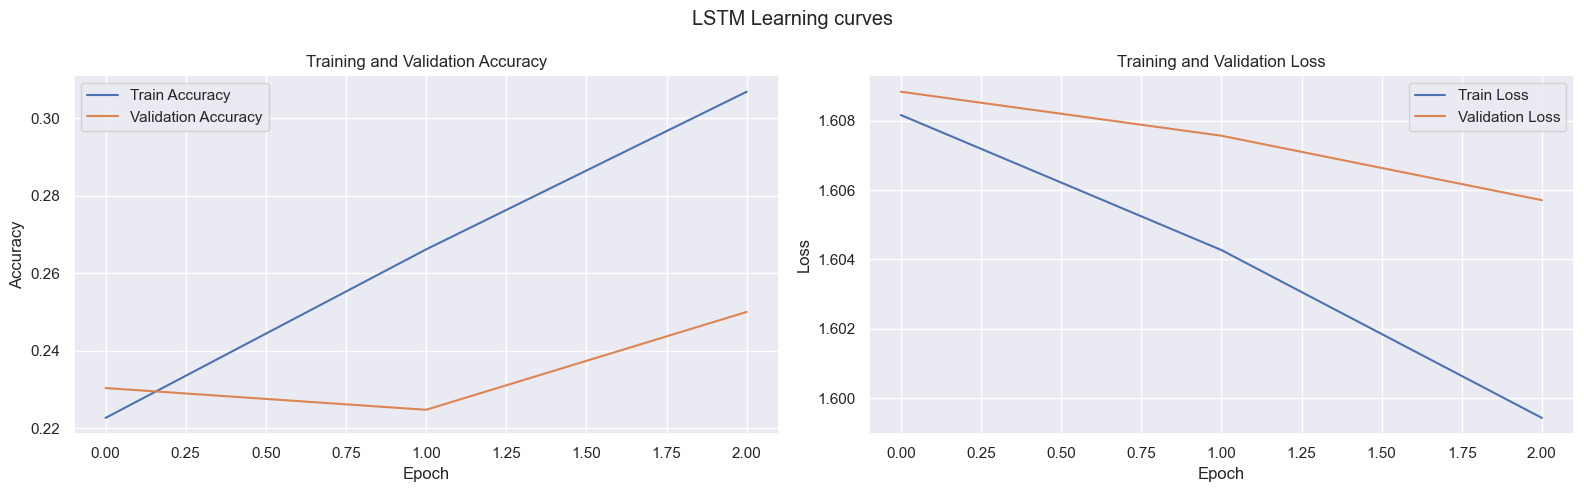

In [77]:
plot_learning_curves("LSTM", history_lstm)

In [78]:
results = model_evalute(lstm_model, "LSTM", results)
pd.DataFrame(results)['LSTM']

14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 108ms/step


Test Accuracy    0.242697
Test Loss        1.606827
F1 Score         0.163914
Name: LSTM, dtype: float64

Ohh, the worse result.. Let's increase learning rate to 0.001 and train again.

In [79]:
lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lstm_model.build(input_shape=(None, MAX_LEN))

In [80]:
history_lstm = lstm_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    callbacks=[early_stopping]
)

Epoch 1/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 17s 260ms/step - accuracy: 0.2676 - loss: 1.5870 - val_accuracy: 0.3399 - val_loss: 1.5818
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 12s 255ms/step - accuracy: 0.5751 - loss: 1.4191 - val_accuracy: 0.5562 - val_loss: 1.1943
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 233ms/step - accuracy: 0.7226 - loss: 0.8642 - val_accuracy: 0.6348 - val_loss: 1.0441
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 254ms/step - accuracy: 0.8553 - loss: 0.6290 - val_accuracy: 0.6404 - val_loss: 0.9680
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 232ms/step - accuracy: 0.9347 - loss: 0.3764 - val_accuracy: 0.8876 - val_loss: 0.4028
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 240ms/step - accuracy: 0.9726 - loss: 0.1283 - val_accuracy: 0.9157 - val_loss: 0.3279
Epoch 7/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 195ms/step - accuracy: 0.9867 - loss: 0.0585 - val_accuracy: 0.9326 - val_loss: 0.2771
Epoch 8/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 200ms/step - accuracy: 0.9874 - loss: 0.0537 - val_accura

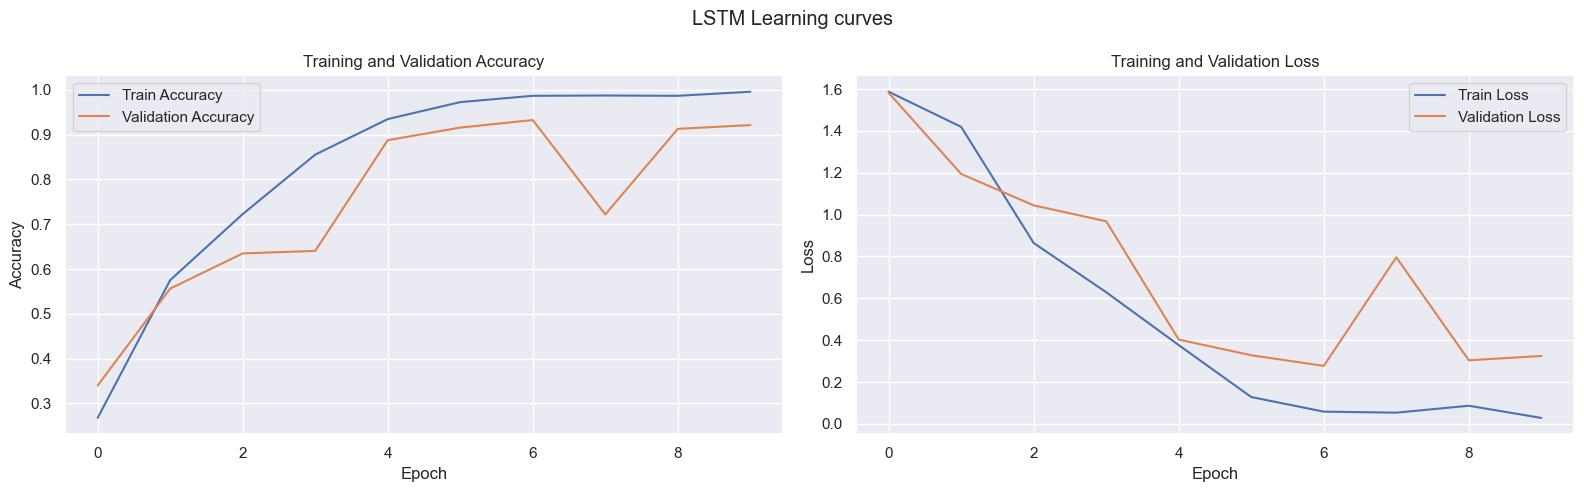

In [81]:
plot_learning_curves("LSTM", history_lstm)

In [82]:
results = model_evalute(lstm_model, "LSTM", results)
pd.DataFrame(results)['LSTM']

14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step


Test Accuracy    0.907865
Test Loss        0.290155
F1 Score         0.908398
Name: LSTM, dtype: float64

Increasing the learning rate from 0.0001 to 0.001 significantly improved convergence.

With the lower learning rate, the model remained close to random performance and failed to learn meaningful patterns within the allotted epochs.
 
Using the default Adam learning rate (0.001) resulted in substantially faster convergence and improved the test accuracy to 90.8% with a weighted F1-score of 90.8%.

## GRU 


To further investigate sequence modeling techniques, a Gated Recurrent Unit (GRU) network was implemented. GRUs are designed to address the vanishing gradient problem of Vanilla RNNs while maintaining a simpler architecture than LSTMs.
- We use same embedding layer.
- We set the GRU layer to processes the input sequence while maintaining a hidden state(with 64 units) that captures contextual information from previous time steps.
- And the same output layer.

In [83]:
from tensorflow.keras.layers import GRU

gru_model = Sequential()

gru_model.add(Embedding(input_dim=MAX_WORDS, output_dim=64, input_length=MAX_LEN, mask_zero=True))

# a GRU layer with hidden size of 64 units
gru_model.add(GRU(64))

gru_model.add(Dense(NUM_CLASSES, activation='softmax'))


gru_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

gru_model.build(input_shape=(None, MAX_LEN))
gru_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 665,285 (2.54 MB)

 Trainable params: 665,285 (2.54 MB)

 Non-trainable params: 0 (0.00 B)

In [87]:
history_gru = gru_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    callbacks=[early_stopping]
)

Epoch 1/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 12s 273ms/step - accuracy: 0.2556 - loss: 1.5555 - val_accuracy: 0.1938 - val_loss: 1.5931
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 10s 216ms/step - accuracy: 0.3862 - loss: 1.4991 - val_accuracy: 0.2697 - val_loss: 1.5626
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 241ms/step - accuracy: 0.5906 - loss: 1.3559 - val_accuracy: 0.3820 - val_loss: 1.4884


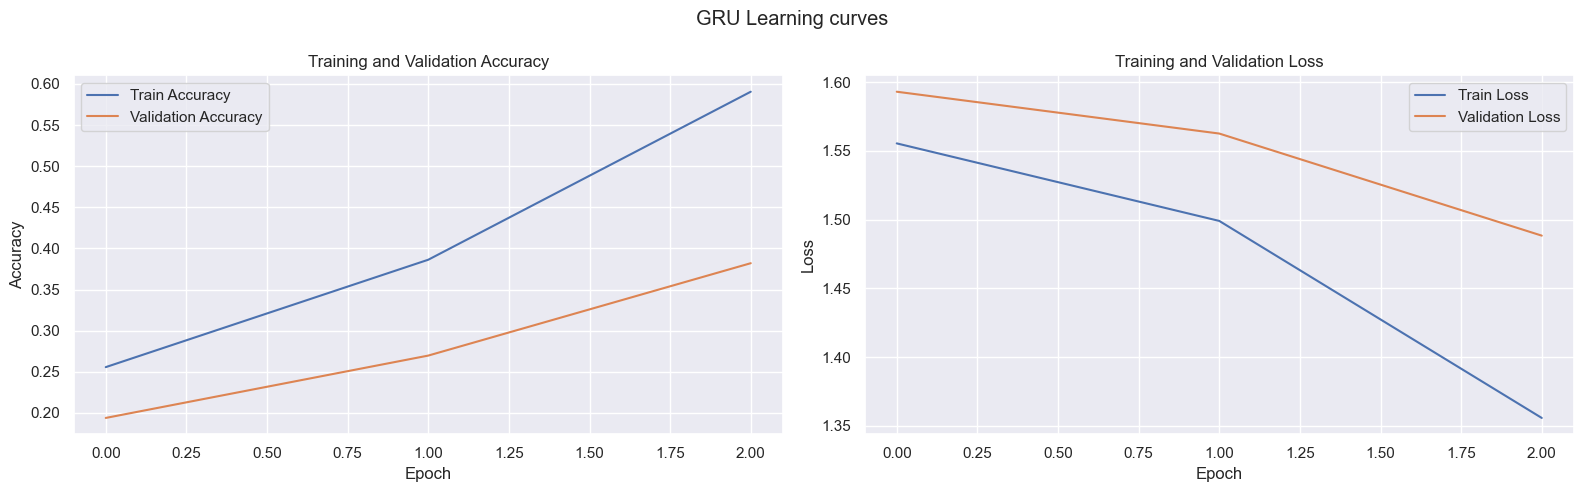

In [88]:
plot_learning_curves("GRU", history_gru)

In [89]:
results = model_evalute(gru_model, "GRU", results)
pd.DataFrame(results)['GRU']

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step


Test Accuracy    0.233708
Test Loss        1.579865
F1 Score         0.094921
Name: GRU, dtype: float64

That is disaster!!!
The GRU model achieved a test accuracy of 23.4% and a weighted F1-score of 0.094% !!

Training and Validation loss both decreased steadily throughout training but training was stopped early.

It may be because early stopping is'nt appropriate or it requiers tuning the hyper parameters.

We recompile the model with learning rate = 0.01

In [90]:
gru_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

gru_model.build(input_shape=(None, MAX_LEN))
gru_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 665,285 (2.54 MB)

 Trainable params: 665,285 (2.54 MB)

 Non-trainable params: 0 (0.00 B)

In [91]:
history_gru = gru_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    callbacks=[early_stopping]
)

Epoch 1/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 17s 267ms/step - accuracy: 0.4607 - loss: 1.3537 - val_accuracy: 0.5281 - val_loss: 1.1865
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 13s 283ms/step - accuracy: 0.8631 - loss: 0.4265 - val_accuracy: 0.6236 - val_loss: 1.3457
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 13s 292ms/step - accuracy: 0.9747 - loss: 0.0904 - val_accuracy: 0.6854 - val_loss: 1.2273


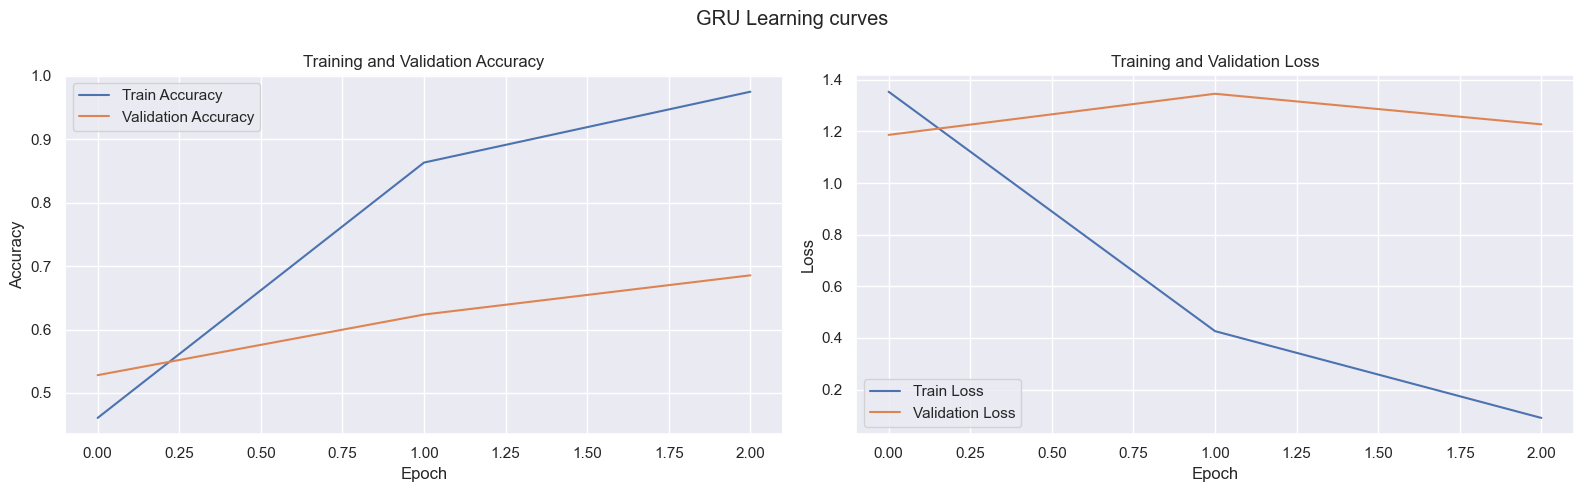

In [92]:
plot_learning_curves("GRU", history_gru)

In [93]:
results = model_evalute(gru_model, "GRU", results)
pd.DataFrame(results)['GRU']

14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step


Test Accuracy    0.566292
Test Loss        1.114638
F1 Score         0.516283
Name: GRU, dtype: float64

Oh. It's better now.

In [95]:
pd.DataFrame(results).T

,Test Accuracy,Test Loss,F1 Score
Vanilla RNN,0.469663,1.268375,0.465910
LSTM,0.907865,0.290155,0.908398
GRU,0.566292,1.114638,0.516283


In [96]:
# save rnn models results for next part of assingment.
pd.DataFrame(results).T.to_csv("rnn_results.csv", index=False)

## Analyze the effects of Core Sequence Modeling Components

The LSTM model was selected as the base architecture for the sequence modeling experiments. Among the three recurrent models evaluated (Vanilla RNN, LSTM, and GRU), LSTM achieved the best overall performance on the BBC News classification task.

At first we define a function to  build a recurrent model based on selected components and a function to fit it and then returns model's scores and results.

In [218]:
from tensorflow.keras.layers import Dropout, Bidirectional

def build_model(
    model_type='LSTM',
    hidden_size=64,
    num_layers=1,
    bidirectional=False,
    dropout_rate=0.0,
    learning_rate=0.001,
    epochs=20,
    batch_size=32
):
    
    model = Sequential()

    # embedding Layer
    model.add(Embedding(input_dim=MAX_WORDS, output_dim=64, mask_zero=True))

    # select recurrent layer
    if model_type == 'RNN':
        RecurrentLayer = SimpleRNN
    elif model_type == 'LSTM':
        RecurrentLayer = LSTM
    elif model_type == 'GRU':
        RecurrentLayer = GRU
    

    # recurrent layers
    for i in range(num_layers):

        return_sequences = (i < num_layers - 1)
        print(return_sequences)

        layer = RecurrentLayer(
            hidden_size,
            return_sequences=return_sequences
        )

        if bidirectional:
            layer = Bidirectional(layer)

        model.add(layer)

        if dropout_rate > 0 and return_sequences:
            model.add(Dropout(dropout_rate))

    # output layer
    model.add(Dense(NUM_CLASSES, activation='softmax'))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model




def run_experiment(name, results,**model_kwargs):
    model = build_model(**model_kwargs)

    # rerun the early stoppping 
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_pad,
        y_train,
        validation_split=0.2,
        epochs=20,
        batch_size=32,
        callbacks=[early_stopping],
        verbose=0
    )

    results = model_evalute(model, name, results)

    return results, history

In [173]:
def plot_all_losses(histories):

    n = len(histories)

    fig, axes = plt.subplots(1, n, figsize=(5*n, 5))

    if n == 1:
        axes = [axes]

    for i, (name, history) in enumerate(histories.items()):

        axes[i].plot(
            history.history['loss'],
            label='Train Loss'
        )

        axes[i].plot(
            history.history['val_loss'],
            label='Validation Loss'
        )

        axes[i].set_title(name)
        axes[i].set_xlabel('Epoch')
        axes[i].set_ylabel('Loss')
        axes[i].legend()
        axes[i].grid(True)

    fig.suptitle('Loss Curves Across Experiments')
    plt.tight_layout()
    plt.show()

In [202]:
def plot_all_val_losses(histories):

    plt.figure(figsize=(8,5))

    for name, history in histories.items():

        plt.plot(
            history.history['val_loss'],
            label=name
        )

    plt.xlabel('Epoch')
    plt.ylabel('Validation Loss')
    plt.title('Validation Loss Comparison')
    plt.legend()
    plt.grid(True)
    plt.show()

### Sequence length

Sequence length determines how many tokens from each article are provided to the model. Since articles in the BBC News dataset vary in length, sequences must be padded or truncated to a fixed size before training.

To experiment this effect, the LSTM architecture was kept fixed while varying only the maximum sequence length:

- 100 tokens
- 200 tokens
- 400 tokens

### 

In [212]:

seq_results = {}
seq_histories ={}

for seq_len in [100, 200, 400]:
    name = f"Lenght {seq_len}"

    X_train_current = pad_sequences(
        X_train_seq,
        maxlen=seq_len,
        padding='post',
        truncating='post'
    )

    X_test_current = pad_sequences(
        X_test_seq,
        maxlen=seq_len,
        padding='post',
        truncating='post'
    )

    model = build_model()

    # rerun the early stoppping 
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_current,
        y_train,
        validation_split=0.2,
        epochs=20,
        batch_size=32,
        callbacks=[early_stopping],
        verbose=0
    )

    test_loss, test_acc = model.evaluate(
    X_test_current,
    y_test,
    verbose=0
    )

    y_pred = np.argmax(model.predict(X_test_current, verbose=0), axis=1)
    f1 = f1_score(y_test, y_pred, average='weighted')

    seq_results[name] = {
        "Test Accuracy":test_acc,
        "Test Loss":test_loss,
        "F1 Score": f1
    }
    seq_histories[name] = history

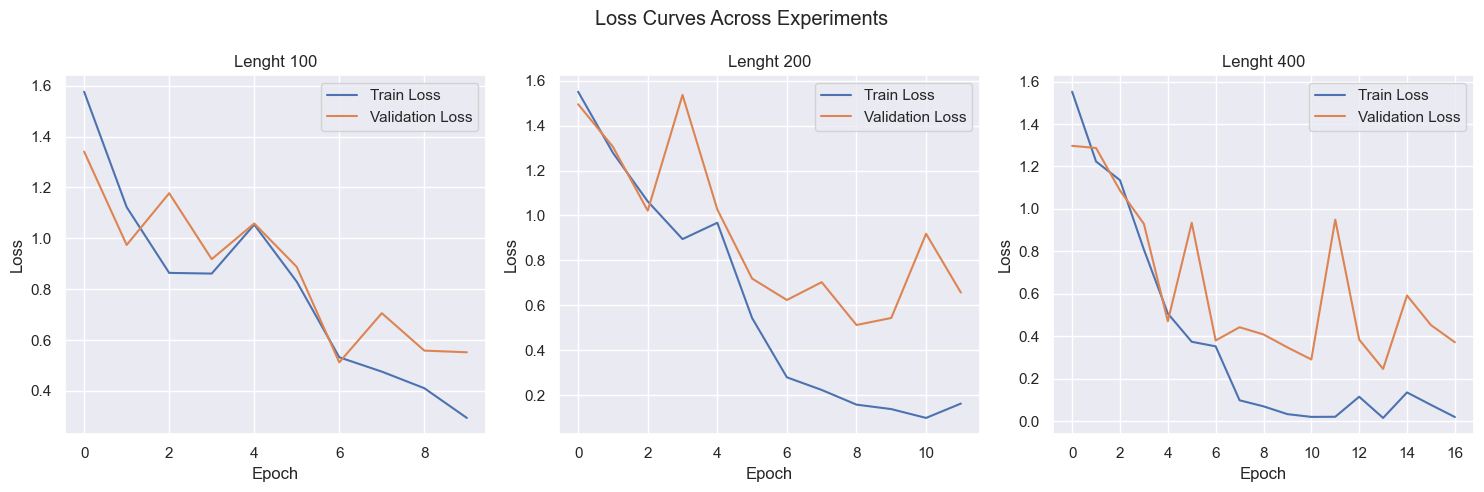

In [213]:
plot_all_losses(seq_histories)

In [214]:
pd.DataFrame(seq_results).T

,Test Accuracy,Test Loss,F1 Score
Lenght 100,0.842697,0.56228,0.842887
Lenght 200,0.849438,0.49713,0.847879
Lenght 400,0.921348,0.27868,0.921630


The results show a clear improvement as the sequence length increases.

- When the sequence length was limited to **100 tokens**, the model achieved approximately **84.3% accuracy**. Although this performance is reasonable, many articles were heavily truncated, causing potentially useful information to be discarded.
- Increasing the sequence length to **200 tokens** produced a small improvement in both accuracy and F1-score. This suggests that the additional context helped the model make better classification decisions.
- The most significant improvement occurred when the sequence length was increased to **400 tokens**, where the model achieved **92.1% accuracy** and **92.2% F1-score**. This indicates that important category-related information often appears beyond the first 200 words of an article, and allowing the model to process a larger portion of each document substantially improved performance.

- For this dataset, longer sequences provided substantially more useful contextual information than shorter sequences. While larger sequence lengths require more computation and memory, a maximum length of **400 tokens** offered the best balance between information retention and predictive performance, resulting in the highest accuracy and F1-score among the tested configurations.


This indicates that shorter sequences overfit to training data by exploiting local patterns, while longer sequences learn more meaningful global article representations that generalize better. 

### Hidden size


The hidden size determines the dimensionality of the recurrent layer's hidden state. In practice, it controls how much information the model can store and process while reading a sequence.

To investigate this effect, the LSTM architecture was kept fixed while varying only the hidden size:

- 32 units
- 64 units
- 128 units

In [193]:
hs_results = {}
hs_histories = {}

for hidden in [32, 64, 128]:
    name = f"Hidden size {hidden}"

    hs_results, hs_histories[name] = run_experiment(name, hs_results, model_type='LSTM', hidden_size=hidden)

c:\Users\kavoshrayan\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 155ms/step


c:\Users\kavoshrayan\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step


c:\Users\kavoshrayan\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step


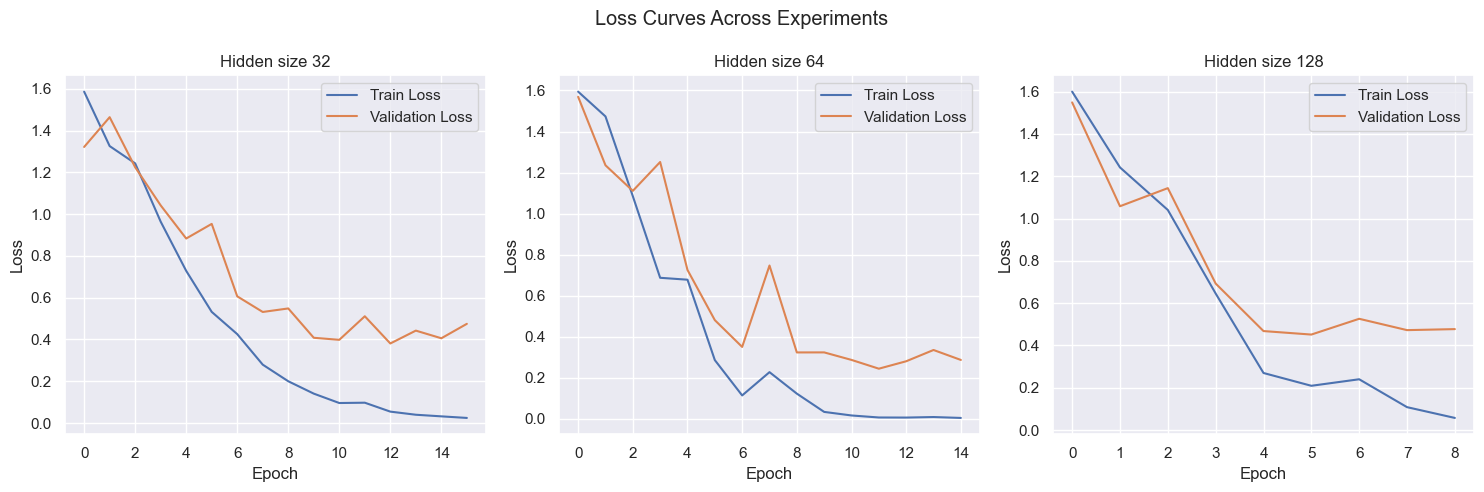

In [198]:
plot_all_losses(hs_histories)

In [199]:
pd.DataFrame(hs_results).T

,Test Accuracy,Test Loss,F1 Score
Hidden size 32,0.858427,0.448006,0.858550
Hidden size 64,0.939326,0.220347,0.939275
Hidden size 128,0.844944,0.454398,0.846489


- With **32 hidden units**, the model achieved approximately **85.8% accuracy**. While the model learned meaningful patterns, its limited capacity likely restricted its ability to capture more complex relationships within the news articles.
- Increasing the hidden size to **64 units** produced the best results, achieving **93.9% accuracy** and the lowest test loss. The learning curves also show a good balance between training and validation performance, indicating that the model had sufficient capacity without severe overfitting.
- When the hidden size was further increased to **128 units**, performance decreased noticeably. Although the training loss continued to decrease rapidly, the validation loss stopped improving and became more unstable. This suggests that the larger model began to overfit the training data and generalized less effectively to unseen examples.
- The 128-unit model converged quickly but showed a larger gap between training and validation loss, whereas the 64-unit model maintained the most stable validation performance.

The results indicate that increasing model capacity is beneficial only up to a certain point. A hidden size of **64 units** provided the best balance between representational power and generalization ability, achieving the highest accuracy and F1-score. Smaller hidden sizes lacked sufficient capacity, while larger hidden sizes increased the risk of overfitting without improving performance.

### One vs multiple recurrent layers

Stacking multiple recurrent layers can increase the representational power of a network by allowing higher layers to learn more abstract sequence features. However, deeper architectures also introduce additional parameters and may be harder to optimize.

To investigate this effect, the LSTM architecture was evaluated using:

- One recurrent layer
- Two stacked recurrent layers

In [219]:
rl_results = {}
rl_histories = {}

for layers in [1, 2]:
    name = f"{layers} recurrent layer(s)"
    rl_results, rl_histories[name] = run_experiment(name, rl_results, model_type='LSTM', num_layers=layers)

False
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step
True
False
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step


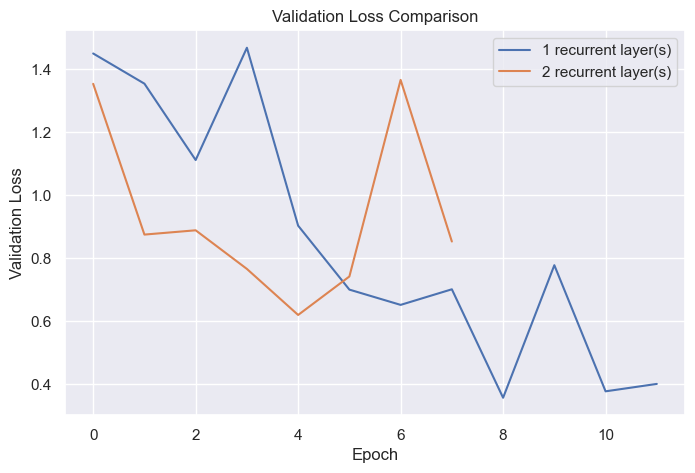

In [220]:
plot_all_val_losses(rl_histories)

In [221]:
pd.DataFrame(rl_results).T

,Test Accuracy,Test Loss,F1 Score
1 recurrent layer(s),0.876405,0.409945,0.873905
2 recurrent layer(s),0.817978,0.551316,0.821419


- The single-layer LSTM achieved the best overall performance, reaching 87.6% accuracy and an F1-score of 87.4%.
- Although the two-layer LSTM initially reduced validation loss, its performance deteriorated after a few epochs and early stopping was triggered sooner. This behavior suggests that the deeper architecture began to overfit the training data and generalized less effectively to unseen examples.

The results indicate that increasing model depth does not necessarily improve performance. For this dataset, a single recurrent layer provided sufficient modeling capacity, while the additional complexity of a second layer introduced optimization challenges and reduced generalization performance.

### Bidirectional RNNs

Undirectional RNNs processes sequences only from left to right (past to future). Each timestep only sees previous tokens, not future ones.

But Bidirectional RNN processes sequences in both directions: one forward pass (left to right) and one backward pass (right to left). The final output combines past and future context.

In [ ]:
br_results = {}
br_histories = {}

for bi in [False, True]:
    name = "Bidirectional" if bi else "Unidirectional"
    br_results, br_histories[name] = run_experiment(name, br_results, model_type='LSTM', bidirectional=bi)

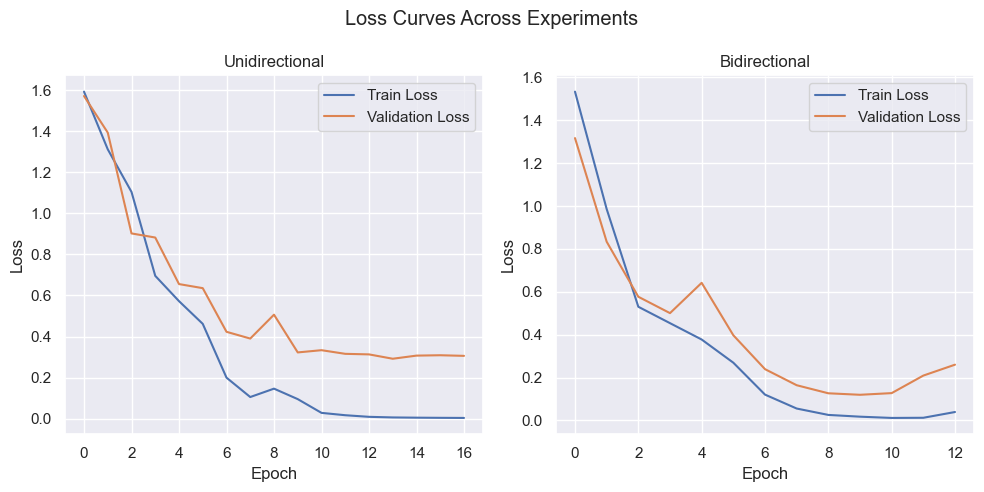

In [ ]:
plot_all_losses(br_histories)

In [ ]:
pd.DataFrame(br_results).T

,Test Accuracy,Test Loss,F1 Score
Unidirectional,0.901124,0.370008,0.902447
Bidirectional,0.943820,0.193012,0.943704


- Bidirectional LSTMs substantially outperform unidirectional models (94.4% vs 90.1% accuracy).
- The loss curves show that bidirectional models maintain lower validation loss throughout training, indicating better generalization. This is because news articles contain dependencies that flow both forward and backward — a unidirectional model cannot capture references where later text clarifies earlier ambiguous terms. 

Actually News articles contain cross-references where later words clarify earlier meaning. Bidirectional LSTMs capture these dependencies, explaining their 4.3% accuracy gain.

### Dropout between recurrent layers

Dropout is a regularization technique that randomly deactivates a fraction of neurons during training. This prevents the network from relying too heavily on specific neurons and helps improve generalization.

To investigate the impact of dropout, a two-layer LSTM architecture was trained using different dropout rates:

- 0.0 (No Dropout)
- 0.3
- 0.5

In [224]:
dr_results = {}
dr_histories = {}

for d in [0.0, 0.3, 0.5]:
    name = f"Dropout {d}"
    dr_results, dr_histories[name] = run_experiment(name, dr_results, model_type='LSTM', num_layers=2, dropout_rate=d)

True
False
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 145ms/step
True
False
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step
True
False
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 202ms/step


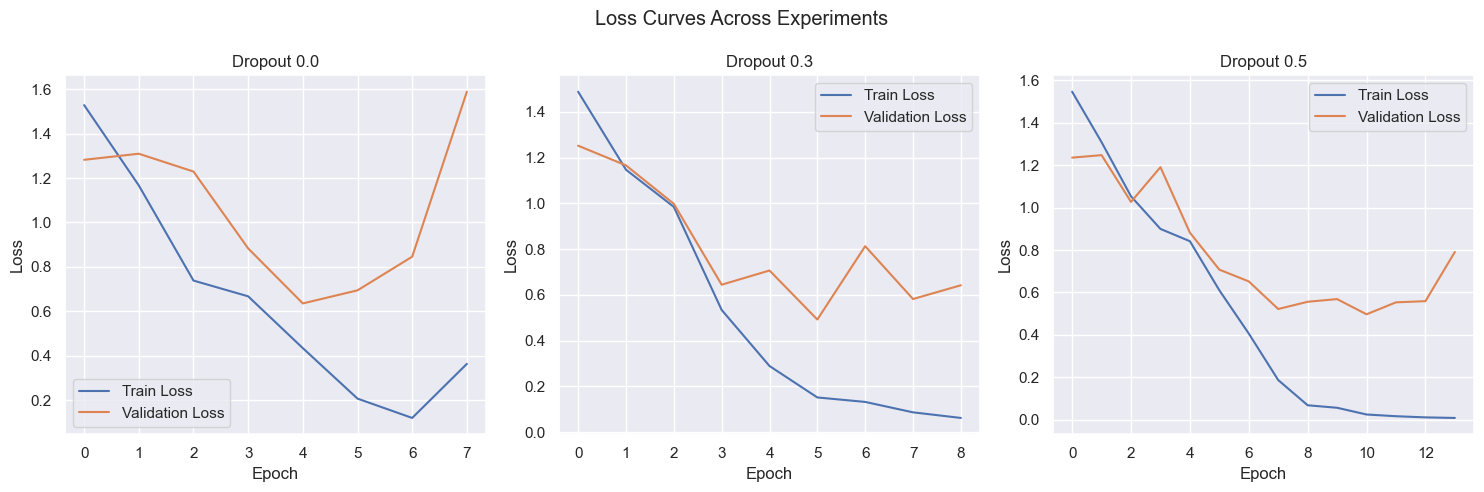

,Test Accuracy,Test Loss,F1 Score
Dropout 0.0,0.820225,0.537003,0.818789
Dropout 0.3,0.865169,0.474887,0.865727
Dropout 0.5,0.889888,0.396246,0.890919


In [225]:
plot_all_losses(dr_histories)
pd.DataFrame(dr_results).T

- Dropout 0.5 forces the LSTM to learn more robust features that generalize better to unseen BBC News articles."
- Without dropout, the model achieved approximately 82.0% accuracy. Introducing a dropout rate of 0.3 improved both accuracy and F1-score, suggesting that the model generalized better to unseen data.
- The best performance was achieved with a dropout rate of 0.5, reaching nearly 89.0% accuracy and obtaining the lowest test loss among all tested configurations.
- The training loss curves converge similarly across all configurations (~0.64), but validation loss reveals the key difference. Without dropout, validation loss remains higher, indicating overfitting.
- This indicates that stronger regularization helped reduce overfitting and encouraged the network to learn more robust representations.

Increasing the dropout rate reduced overfitting and improved generalization performance. Among the tested values, a dropout rate of 0.5 achieved the best overall results, providing the highest accuracy and F1-score.

## Discussion Question

### Why are LSTMs and GRUs generally better than vanilla RNNs for long sequences?

Vanilla RNNs struggle with long sequences because of the **vanishing gradient problem**. During training, gradients are repeatedly multiplied by weight matrices and activation derivatives across many time steps and can become extremely small. As a result, the network gradually loses information from earlier parts of the sequence and has difficulty learning long-term dependencies. Then vanilla RNNs tend to forget long-term information and focus mostly on recent inputs.

LSTMs and GRUs fix this by introducing gating mechanisms that control what information is kept, updated, or discarded. These gates act like learned flow controllers for information and gradients.


### Explain the role of gates and how they help with vanishing gradients and long-term dependencies

An LSTM uses three gates:

- **Forget Gate:** decides what information should be discarded.
- **Input Gate:** decides what new information should be stored.
- **Output Gate:** decides what information should be passed to the next step.

In addition, LSTMs maintain a dedicated **cell state**, which acts as long-term memory and provides a more stable path for gradient flow.


A GRU is a simplified version of the LSTM that uses:

- **Update Gate:** controls how much past information should be retained.
- **Reset Gate:** controls how much past information should be ignored.

Although GRUs have fewer parameters than LSTMs, they can still effectively capture long-range dependencies.

Both LSTMs and GRUs reduce vanishing gradients because they create paths where information (and gradients) can pass through many time steps with less repeated nonlinear squashing. Instead of forcing everything through a single transformation each step (like vanilla RNNs), gates allow the model to preserve important signals over long distances.